In [2]:
!pip install face_recognition
import cv2
import face_recognition
import numpy as np
from datetime import datetime
import time
from google.colab import files
import os
import pandas as pd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=b13eb94a8bbdbf94412d15fcea8b12997095c6cf16b45d5738dd13a40c6c3709
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [3]:
print("=== INTRUDER DETECTION SYSTEM ===")
print("Upload FAMILY/AUTHORIZED faces (home_members.jpg)")
files.upload()

family_encodings = []
family_names = []

for filename in os.listdir('.'):
    if filename.endswith(('.jpg', '.jpeg', '.png')):
        name = os.path.splitext(filename)[0]
        image = face_recognition.load_image_file(filename)
        encoding = face_recognition.face_encodings(image)
        if encoding:
            family_encodings.append(encoding[0])
            family_names.append(name)
            print(f"✅ Authorized: {name}")


=== INTRUDER DETECTION SYSTEM ===
Upload FAMILY/AUTHORIZED faces (home_members.jpg)


Saving 2.jpg to 2.jpg
✅ Authorized: 2


In [4]:
RESTRICTED_START = 22  # 10 PM
RESTRICTED_END = 6     # 6 AM

def is_restricted_time():
    now = datetime.now()
    current_hour = now.hour
    return current_hour >= RESTRICTED_START or current_hour < RESTRICTED_END

def log_event(name, is_intruder, time_restricted):
    with open('security_log.csv', 'a') as f:
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        event_type = "INTRUDER" if is_intruder else "Family Member"
        time_status = "RESTRICTED HOUR" if time_restricted else "Normal Hour"
        f.write(f"{timestamp},{name},{event_type},{time_status}\n")

def send_alert(name, time_restricted):
    print("\n" + "="*50)
    print("🚨 ALERT! 🚨")
    if time_restricted:
        print(f"⚠️ INTRUDER DETECTED at RESTRICTED TIME: {name}")
    else:
        print(f"⚠️ UNKNOWN FACE DETECTED: {name}")
    print("📧 Email/SMS alert would be sent here")
    print("="*50 + "\n")

In [5]:
print("\n📸 Upload surveillance snapshots (test images)")
print("Will detect faces and check for intruders")
files.upload()


📸 Upload surveillance snapshots (test images)
Will detect faces and check for intruders


Saving 2.jpg to 2 (1).jpg


{'2 (1).jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x01,\x01,\x00\x00\xff\xe1\x01\x0eExif\x00\x00II*\x00\x08\x00\x00\x00\x03\x00\x0e\x01\x02\x00\xc4\x00\x00\x002\x00\x00\x00\x1a\x01\x05\x00\x01\x00\x00\x00\xf6\x00\x00\x00\x1b\x01\x05\x00\x01\x00\x00\x00\xfe\x00\x00\x00\x00\x00\x00\x00College student, asian man and studying on laptop at campus, research and education test, exam books and course project. Happy Japanese university student, knowledge and learning online technology,\x01\x00\x00\x01\x00\x00\x00,\x01\x00\x00\x01\x00\x00\x00\xff\xe1\x067http://ns.adobe.com/xap/1.0/\x00<?xpacket begin="\xef\xbb\xbf" id="W5M0MpCehiHzreSzNTczkc9d"?>\n<x:xmpmeta xmlns:x="adobe:ns:meta/">\n\t<rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">\n\t\t<rdf:Description rdf:about="" xmlns:photoshop="http://ns.adobe.com/photoshop/1.0/" xmlns:Iptc4xmpCore="http://iptc.org/std/Iptc4xmpCore/1.0/xmlns/"   xmlns:GettyImagesGIFT="http://xmp.gettyimages.com/gift/1.0/" xmlns:dc="http://purl

In [6]:
for img_file in os.listdir('.'):
    if img_file.endswith(('.jpg', '.jpeg', '.png')) and img_file not in family_names:
        print(f"\n🔍 Analyzing: {img_file}")

        frame = face_recognition.load_image_file(img_file)
        face_locations = face_recognition.face_locations(frame)
        face_encodings = face_recognition.face_encodings(frame, face_locations)

        restricted = is_restricted_time()
        current_time = datetime.now().strftime("%H:%M")

        print(f"🕐 Current time: {current_time} - {'RESTRICTED HOURS' if restricted else 'Normal hours'}")

        for face_encoding in face_encodings:
            matches = face_recognition.compare_faces(family_encodings, face_encoding)

            if True in matches:
                match_index = matches.index(True)
                name = family_names[match_index]
                print(f"✅ Recognized: {name} (Authorized)")
                log_event(name, False, restricted)
            else:
                print(f"❌ UNKNOWN face detected!")
                log_event("Unknown", True, restricted)

                if restricted:
                    send_alert("Unknown person", True)
                else:
                    print("ℹ️ Unknown face but during normal hours - logged only")



🔍 Analyzing: 2 (1).jpg
🕐 Current time: 14:48 - Normal hours
✅ Recognized: 2 (Authorized)

🔍 Analyzing: 2.jpg
🕐 Current time: 14:48 - Normal hours
✅ Recognized: 2 (Authorized)


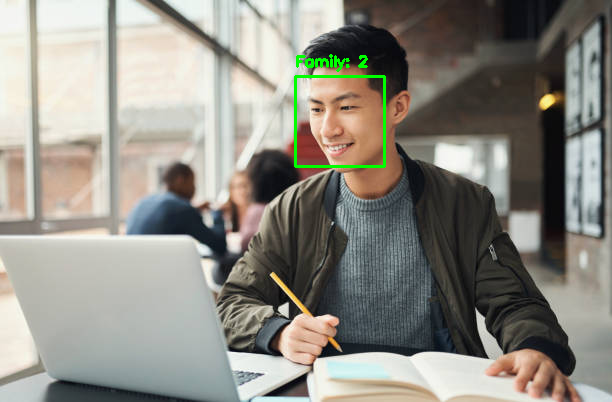

In [8]:
img_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
    matches = face_recognition.compare_faces(family_encodings, face_encoding)
    if True in matches:
        color = (0,255,0)
        label = f"Family: {family_names[matches.index(True)]}"
    else:
        color = (0,0,255)
        label = "INTRUDER"
        if restricted:
            label = "🚨 INTRUDER - ALERT 🚨"

    cv2.rectangle(img_bgr, (left, top), (right, bottom), color, 2)
    cv2.putText(img_bgr, label, (left, top-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

from google.colab.patches import cv2_imshow
cv2_imshow(img_bgr)